# Approach 15: ECG-FM with Temporal Attention

Passes ECG through the ECG-FM (wav2vec 2.0) encoder, then applies temporal attention over the sequence to predict Chagas. Attention weights are plotted per time step.

In [1]:
import os
import sys
import time
import logging
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, confusion_matrix,
    f1_score, roc_curve, precision_recall_curve,
)
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

sns.set_context("notebook")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 5)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("chagas")

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"PyTorch {torch.__version__} | Device : {device}")

/Users/jwasieleski/Prywatne/jul/workspace/magisterka/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch 2.10.0 | Device : mps


In [2]:
CFG = {
    "preprocessed_cache": "preprocessed_cache_brazil.h5",
    "val_fraction": 0.15,
    "test_fraction": 0.15,
    "random_seed": 42,
    "target_fs": 500,
    "target_duration_s": 10,
    
    "fm_weights_path": "DeepECG_Docker-main/ssl_pretrained_model/SSL_pretrained.pt",
    "fairseq_path": "DeepECG_Docker-main/fairseq-signals",
    "deepecg_path": "DeepECG_Docker-main",
    
    "epochs": 20,
    "batch_size": 32,
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "num_workers": 0,
    
    "focal_alpha": 0.25,
    "focal_gamma": 2.0,
}

torch.manual_seed(CFG["random_seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CFG["random_seed"])

In [3]:
sys.path.append(os.path.abspath(CFG["deepecg_path"]))
sys.path.append(os.path.abspath(CFG["fairseq_path"]))

from fairseq_signals.utils import checkpoint_utils

def load_fm_encoder(weights_path, device):
    model, cfg, task = checkpoint_utils.load_model_and_task(
        weights_path,
        suffix=""
    )
    model.eval()
    model.to(device)
    return model

print(f"Loading FM Encoder from {CFG['fm_weights_path']}")
fm_encoder = load_fm_encoder(CFG["fm_weights_path"], device)
for param in fm_encoder.parameters():
    param.requires_grad = False

Loading FM Encoder from DeepECG_Docker-main/ssl_pretrained_model/SSL_pretrained.pt


18:13:08 [INFO] Loaded a checkpoint in 2.11s


In [4]:
class TemporalAttentionFusion(nn.Module):
    def __init__(self, fm_encoder, embed_dim=768, num_heads=4):
        super().__init__()
        self.fm_encoder = fm_encoder
        
        self.query = nn.Parameter(torch.randn(1, 1, embed_dim))
        
        self.attention = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.norm = nn.LayerNorm(embed_dim)
        
        self.head = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1)
        )

    def train(self, mode=True):
        super().train(mode)
        self.fm_encoder.eval()
        return self

    def forward(self, x, return_attention=False):
        with torch.no_grad():
            out = self.fm_encoder(source=x, padding_mask=None, features_only=True)
            features = out["x"]
            if features.size(0) != x.size(0) and features.size(1) == x.size(0):
                features = features.transpose(0, 1)
                
        B = features.size(0)
        q = self.query.expand(B, -1, -1)
        
        attn_out, attn_weights = self.attention(q, features, features)
        
        pooled = attn_out.squeeze(1)
        pooled = self.norm(pooled)
        
        logits = self.head(pooled).view(-1)
        
        if return_attention:
            return logits, attn_weights
        return logits

model = TemporalAttentionFusion(fm_encoder).to(device)

In [5]:
cache_file = CFG["preprocessed_cache"]
assert Path(cache_file).exists(), f"Missing {cache_file} — run chagas_resnet_classifier.ipynb first."

with h5py.File(cache_file, "r") as f:
    n_total = f["labels"].shape[0]
    all_labels = f["labels"][:]
    all_exam_ids = f["exam_ids"][:] if "exam_ids" in f else np.arange(n_total)

code15_dir = "4916206"
samitrop_dir = "sami-trop"

df_code15 = pd.read_csv(os.path.join(code15_dir, "exams.csv")) if os.path.exists(os.path.join(code15_dir, "exams.csv")) else pd.DataFrame()
df_samitrop = pd.read_csv(os.path.join(samitrop_dir, "exams.csv")) if os.path.exists(os.path.join(samitrop_dir, "exams.csv")) else pd.DataFrame()

if not df_code15.empty: df_code15["source"] = "code15"
if not df_samitrop.empty: df_samitrop["source"] = "samitrop"

df_meta = pd.concat([df_code15, df_samitrop], ignore_index=True)

if not df_meta.empty and "exam_id" in df_meta.columns and "patient_id" in df_meta.columns:
    exam_to_patient = dict(zip(df_meta["exam_id"], df_meta["patient_id"]))
    exam_to_source = dict(zip(df_meta["exam_id"], df_meta["source"]))
    
    patient_ids = np.array([exam_to_patient.get(eid, eid) for eid in all_exam_ids])
    sources = np.array([exam_to_source.get(eid, "unknown") for eid in all_exam_ids])
else:
    raise ValueError("Missing patient metadata\! Cannot perform safe grouped split. Check exams.csv")

from sklearn.model_selection import train_test_split

code15_mask = (sources == "code15")
samitrop_mask = (sources == "samitrop")
code15_indices = np.where(code15_mask)[0]
samitrop_indices = np.where(samitrop_mask)[0]

code15_labels = all_labels[code15_indices]
trainval_idx, test_idx_rel = train_test_split(
    np.arange(len(code15_indices)),
    test_size=CFG["test_fraction"],
    stratify=code15_labels,
    random_state=CFG["random_seed"]
)
train_idx_rel, val_idx_rel = train_test_split(
    trainval_idx,
    test_size=CFG["val_fraction"] / (1.0 - CFG["test_fraction"]),
    stratify=code15_labels[trainval_idx],
    random_state=CFG["random_seed"]
)
train_indices = code15_indices[train_idx_rel]
val_indices   = code15_indices[val_idx_rel]
test_indices  = code15_indices[test_idx_rel]

print(f"Train : {len(train_indices):,} samples | Chagas+ {all_labels[train_indices].mean():.1%}")
print(f"Val   : {len(val_indices):,} samples | Chagas+ {all_labels[val_indices].mean():.1%}")
print(f"Test  : {len(test_indices):,} samples | Chagas+ {all_labels[test_indices].mean():.1%}")
print(f"SaMi-Trop OOD: {len(samitrop_indices):,} samples | Chagas+ {all_labels[samitrop_indices].mean():.1%}")

class CachedChagasDataset(Dataset):
    def __init__(self, cache_path, indices):
        self.cache_path = cache_path
        self.indices = np.sort(indices)
        self._file = None
        with h5py.File(cache_path, "r") as f:
            self.labels = f["labels"][self.indices]

    def __len__(self):
        return len(self.indices)

    def _f(self):
        if self._file is None:
            self._file = h5py.File(self.cache_path, "r")
        return self._file

    def __getitem__(self, idx):
        f = self._f()
        ri = self.indices[idx]
        x = torch.from_numpy(f["signals"][ri]).float()
        if x.size(0) == 5000 and x.size(1) == 12:
            x = x.transpose(0, 1)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

pin = device.type == "cuda"
train_loader = DataLoader(CachedChagasDataset(cache_file, train_indices), batch_size=CFG["batch_size"], shuffle=True, pin_memory=pin, drop_last=True)
val_loader = DataLoader(CachedChagasDataset(cache_file, val_indices), batch_size=CFG["batch_size"], shuffle=False, pin_memory=pin)
test_loader = DataLoader(CachedChagasDataset(cache_file, test_indices), batch_size=CFG["batch_size"], shuffle=False, pin_memory=pin)
samitrop_loader = DataLoader(CachedChagasDataset(cache_file, samitrop_indices), batch_size=CFG["batch_size"], shuffle=False, pin_memory=pin)

<>:28: SyntaxWarning: invalid escape sequence '\!'
<>:28: SyntaxWarning: invalid escape sequence '\!'
/var/folders/zf/8wzrl6dx2hqc67b9kdstrs0r0000gn/T/ipykernel_27517/301782662.py:28: SyntaxWarning: invalid escape sequence '\!'
  raise ValueError("Missing patient metadata\! Cannot perform safe grouped split. Check exams.csv")


Train : 33,263 samples | Chagas+ 13.8%
Val   : 7,129 samples | Chagas+ 13.8%
Test  : 7,129 samples | Chagas+ 13.8%
SaMi-Trop OOD: 1,631 samples | Chagas+ 100.0%


In [6]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        targets = targets.float()
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        pt = torch.exp(-bce)
        at = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        return (at * (1 - pt).pow(self.gamma) * bce).mean()

@dataclass
class EvalResult:
    auroc: float
    auprc: float
    f1: float
    sens: float
    spec: float
    thr: float = 0.5

def compute_metrics(y_true, y_prob, thr=None):
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    if len(np.unique(y_true)) < 2:
        return EvalResult(float("nan"), float("nan"), 0.0, 0.0, 0.0, 0.5)
    
    auroc = roc_auc_score(y_true, y_prob)
    auprc = average_precision_score(y_true, y_prob)
    
    if thr is None:
        precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
        f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
        optimal_idx = np.argmax(f1_scores)
        thr = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5

    yp = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, yp, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    f1 = f1_score(y_true, yp, zero_division=0)
    
    return EvalResult(auroc, auprc, f1, sens, spec, float(thr))

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for x, y in tqdm(loader, leave=False):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def evaluate(model, loader, device, thr=None):
    model.eval()
    all_preds, all_targets = [], []
    total_loss = 0
    criterion = FocalLoss(alpha=CFG["focal_alpha"], gamma=CFG["focal_gamma"]).to(device)
    
    for x, y in tqdm(loader, leave=False):
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item()
        
        probs = torch.sigmoid(logits)
        all_preds.extend(probs.cpu().numpy())
        all_targets.extend(y.cpu().numpy())
        
    metrics = compute_metrics(all_targets, all_preds, thr=thr)
    return total_loss / len(loader), metrics

In [7]:
CKPT = "approach15_attention_code15_best.pt"

if os.path.exists(CKPT):
    ckpt = torch.load(CKPT, map_location=device)
    model.load_state_dict(ckpt["state_dict"])
    best_thr = ckpt["val_thr"]
    print(f"Loaded checkpoint from {CKPT}, skipping training. Threshold: {best_thr:.4f}")
else:
    print("Training Attention Model")

    optimizer = AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
    criterion = FocalLoss(alpha=CFG["focal_alpha"], gamma=CFG["focal_gamma"]).to(device)

    best_val_auprc = 0.0
    for epoch in range(CFG["epochs"]):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, metrics = evaluate(model, val_loader, device)

        print(f"Epoch {epoch+1}/{CFG['epochs']} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val AUROC: {metrics.auroc:.4f} | Val AUPRC: {metrics.auprc:.4f} | Val F1: {metrics.f1:.4f} (thr={metrics.thr:.3f})")

        if metrics.auprc > best_val_auprc:
            best_val_auprc = metrics.auprc
            torch.save({
                "state_dict": model.state_dict(),
                "val_thr": metrics.thr
            }, CKPT)

    ckpt = torch.load(CKPT, map_location=device)
    best_thr = ckpt["val_thr"]
    print(f"Training complete. Best val AUPRC: {best_val_auprc:.4f}, Threshold: {best_thr:.4f}")

Training Attention Model


Epoch 1/20 | Train Loss: 0.0323 | Val Loss: 0.0335 | Val AUROC: 0.8138 | Val AUPRC: 0.4445 | Val F1: 0.4527 (thr=0.226)


Epoch 2/20 | Train Loss: 0.0310 | Val Loss: 0.0306 | Val AUROC: 0.8233 | Val AUPRC: 0.4595 | Val F1: 0.4726 (thr=0.312)


Epoch 3/20 | Train Loss: 0.0309 | Val Loss: 0.0307 | Val AUROC: 0.8239 | Val AUPRC: 0.4644 | Val F1: 0.4715 (thr=0.275)


Epoch 4/20 | Train Loss: 0.0307 | Val Loss: 0.0307 | Val AUROC: 0.8190 | Val AUPRC: 0.4631 | Val F1: 0.4674 (thr=0.286)


...

Epoch 16/20 | Train Loss: 0.0301 | Val Loss: 0.0302 | Val AUROC: 0.8307 | Val AUPRC: 0.4768 | Val F1: 0.4753 (thr=0.293)


Epoch 17/20 | Train Loss: 0.0302 | Val Loss: 0.0304 | Val AUROC: 0.8277 | Val AUPRC: 0.4695 | Val F1: 0.4715 (thr=0.290)


Epoch 18/20 | Train Loss: 0.0301 | Val Loss: 0.0304 | Val AUROC: 0.8294 | Val AUPRC: 0.4763 | Val F1: 0.4813 (thr=0.301)


Epoch 19/20 | Train Loss: 0.0300 | Val Loss: 0.0310 | Val AUROC: 0.8231 | Val AUPRC: 0.4678 | Val F1: 0.4626 (thr=0.304)


Epoch 20/20 | Train Loss: 0.0300 | Val Loss: 0.0308 | Val AUROC: 0.8265 | Val AUPRC: 0.4666 | Val F1: 0.4680 (thr=0.270)
Training complete. Best val AUPRC: 0.4772, Threshold: 0.2756


In [8]:
ckpt = torch.load("approach15_attention_code15_best.pt")
model.load_state_dict(ckpt["state_dict"])
best_thr = ckpt["val_thr"]

test_loss, metrics = evaluate(model, test_loader, device, thr=best_thr)
print(f"Test AUROC: {metrics.auroc:.4f} | Test AUPRC: {metrics.auprc:.4f} | Test F1: {metrics.f1:.4f} | Test Sens: {metrics.sens:.4f} | Test Spec: {metrics.spec:.4f} | Thr: {best_thr:.3f}")

Test AUROC: 0.8351 | Test AUPRC: 0.5119 | Test F1: 0.4837 | Test Sens: 0.5427 | Test Spec: 0.8877 | Thr: 0.276


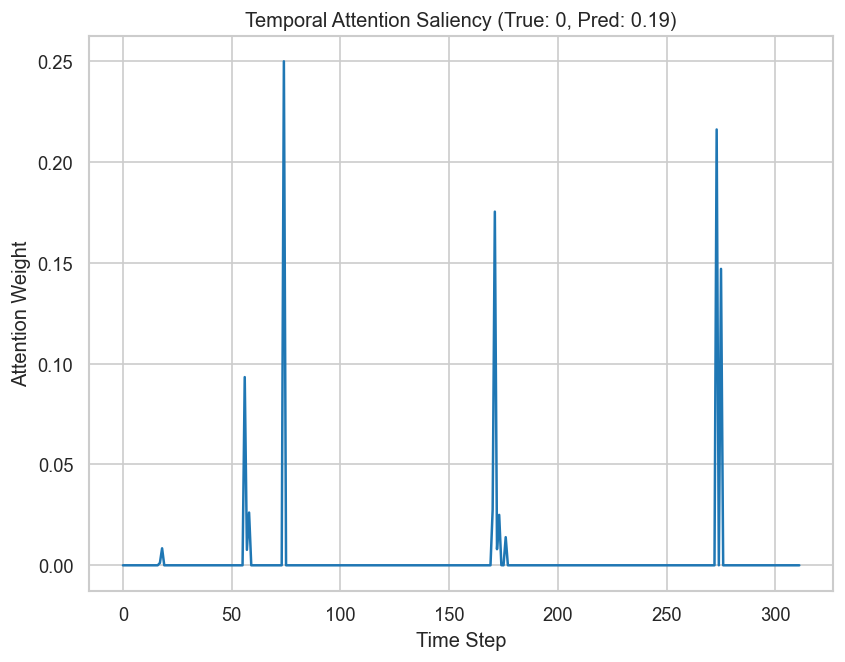

In [9]:
model.eval()
x, y = next(iter(test_loader))
x = x.to(device)
with torch.no_grad():
    logits, attn_weights = model(x, return_attention=True)

plt.figure(figsize=(8, 6))
plt.plot(attn_weights[0, 0].cpu().numpy())
plt.title(f"Temporal Attention Saliency (True: {y[0].item()}, Pred: {torch.sigmoid(logits[0]).item():.2f})")
plt.xlabel("Time Step")
plt.ylabel("Attention Weight")
plt.show()

## SaMi-Trop OOD Evaluation (Domain Shift Analysis)

SaMi-Trop is an independent Chagas cohort from an endemic zone, with a different hospital, different equipment, and different patient population from CODE-15%. The model was trained and validated only on CODE-15% (Brazilian general hospital).

SaMi-Trop contains only Chagas-positive patients (single-class), so standard binary metrics (AUROC, AUPRC) are undefined. Sensitivity is reported: the fraction of confirmed Chagas patients the model flags.

This tests cross-domain generalization, i.e. whether the model learned a Chagas signature or only CODE-15%-specific patterns.

In [ ]:
ckpt = torch.load("approach15_attention_code15_best.pt", map_location=device)
model.load_state_dict(ckpt["state_dict"])
best_thr = ckpt["val_thr"]
model.eval()

all_probs = []
with torch.no_grad():
    for x, y in samitrop_loader:
        x = x.to(device)
        logits = model(x)
        probs = torch.sigmoid(logits)
        all_probs.extend(probs.cpu().numpy())

all_probs = np.array(all_probs)
sensitivity = (all_probs >= best_thr).mean()
print("=" * 50)
print("SAMITROP OOD EVALUATION (domain shift)")
print("=" * 50)
print(f"  N samples  : {len(all_probs)} (100% Chagas+)")
print(f"  Threshold  : {best_thr:.4f} (from CODE-15% val)")
print(f"  Sensitivity: {sensitivity:.4f} ({int(sensitivity*len(all_probs))}/{len(all_probs)} detected)")
print(f"  Mean prob  : {all_probs.mean():.4f}")
print("=" * 50)
print("AUROC/AUPRC undefined for single-class set.")